<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Monte_Carlo_Liverpool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [130]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
import math
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from tabulate import tabulate

#Liverpool

In [131]:
#Obtener datos
df = yf.download('LIVEPOL1.MX', start='2024-01-01', end ='2026-06-26')

/tmp/ipykernel_26803/2057216176.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('LIVEPOL1.MX', start='2024-01-01', end ='2026-06-26')
[*********************100%***********************]  1 of 1 completed


In [132]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [133]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Rendimientos Logarítmicos

In [134]:
#Obtener datos
precios = df['Close']

In [135]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))

In [136]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-06-19    0.000000
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.004819
2026-06-25    0.000000
Name: Rendimientos_Log, Length: 620, dtype: float64


#Monte Carlo

In [137]:
rendimientos = df['Rendimientos_Log']

In [138]:
#Se calcula la media de los rendimientos
media_rendimientos = rendimientos.mean()
print(f"La media de los rendimientos es: {media_rendimientos:.6f}")

La media de los rendimientos es: -0.000111


In [139]:
#Calculamos la desviación estándar
desviacion_rendimientos = rendimientos.std()
print(f"La desviación de los rendimientos es: {desviacion_rendimientos:.6f}")

La desviación de los rendimientos es: 0.013465


#Prueba con datos entrenamiento

In [140]:
train = precios[:-100]
test = precios[-100:]

In [141]:
#Calcular los rendimientos del entrenamiento
rend_train = np.log(precios / precios.shift(1)).dropna()
print(rend_train)

Date
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-06-19    0.000000
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.004819
2026-06-25    0.000000
Name: Close, Length: 620, dtype: float64


In [142]:
#Calcular media y desviación estándar
media_rendimientos_train = rend_train.mean()
desviacion_rendimientos_train = rend_train.std()

In [143]:
print(f"La media de los rendimientos es: {media_rendimientos_train:.4f}")
print(f"La desviación de los rendimientos es: {desviacion_rendimientos_train:.4f}")

La media de los rendimientos es: -0.0001
La desviación de los rendimientos es: 0.0135


In [144]:
#Último precio conocido de los datos de entrenamiento
ultimo_precio_cierre_train = train.iloc[-1]

In [145]:
print(f"El último precio de los datos de entrenamiento es: ${ultimo_precio_cierre_train:.4f}")

El último precio de los datos de entrenamiento es: $100.2830


In [146]:
num_dias_a_pproyectar = 100
num_ssimulaciones = 100

In [147]:
# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulaciones_prueba = []

In [148]:
#Para fijar los números aleatorios
np.random.seed(1)

In [149]:
for _ in range(num_ssimulaciones):
    # Para cada simulación, empezar con el último precio conocido
    ppronosticos = [ultimo_precio_cierre_train]
    for _ in range(num_dias_a_pproyectar):
        # Generar números aleatorios basado
        aleatoriop = np.random.normal(0, 1)
        # Calcular el siguiente precio
        dt = 1/252
        pprecio_siguiente = ppronosticos[-1] * np.exp((media_rendimientos_train - 0.5 * desviacion_rendimientos_train**2) * dt + desviacion_rendimientos_train * np.sqrt(dt) * aleatoriop)
        ppronosticos.append(pprecio_siguiente)
    monte_carlo_simulaciones_prueba.append(ppronosticos)

In [150]:
ssimulaciones = np.array(monte_carlo_simulaciones_prueba)

# Elimina el precio inicial
ssimulaciones = ssimulaciones[:, 1:]

pprecio_esperado = ssimulaciones.mean(axis=0)

In [151]:
#Comparar con datos reales
comparacionp = pd.DataFrame({
    "Real": test.values,
    "MonteCarlo": pprecio_esperado
}, index=test.index)

print(comparacionp)

                  Real  MonteCarlo
Date                              
2026-01-29  100.283028  100.280342
2026-01-30  102.839256  100.281584
2026-02-03  102.839256  100.289545
2026-02-04  102.858925  100.290617
2026-02-05  102.858925  100.288587
...                ...         ...
2026-06-19  103.500000  100.371051
2026-06-22  103.500000  100.363485
2026-06-23  103.500000  100.360660
2026-06-24  104.000000  100.370503
2026-06-25  104.000000  100.361712

[100 rows x 2 columns]


##Estadísticos de Bondad de Ajuste

###Error Cuadrático Medio (RMSE)


In [152]:
rmse = math.sqrt(mean_squared_error(test, pprecio_esperado))
print(f"RMSE Monte Carlo: {rmse:.4f}")

RMSE Monte Carlo: 5.0866


In [153]:
rmse_porcentaje = (rmse / test.mean()) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 4.8489 %


###Error Cuadrático Medio (MAE)

In [154]:
mae = mean_absolute_error(test, pprecio_esperado)

print(f"MAE Monte Carlo: {mae:.4f}")

MAE Monte Carlo: 4.5531


In [155]:
mae_porcentaje = (mae / test.mean()) * 100
print(f"% MAE Monte Carlo: {mae_porcentaje:.4f} %")

% MAE Monte Carlo: 4.3404 %


###Error Porcentual Absoluto Medio (MAPE)

In [156]:
# Using scikit-learn
mape = mean_absolute_percentage_error(test, pprecio_esperado) * 100
print(f"MAPE: {mape:.4f}%")

MAPE: 4.2959%


#Predicción para 100 días a partir del 29/06/26

In [157]:
# Definir el número de simulaciones (escenarios) y el número de días a proyectar
num_simulaciones = 100 # Número de escenarios Monte Carlo
num_dias_a_proyectar = 100 # Número de días en el futuro para cada simulación

In [158]:
# Obtener el último precio de cierre del DataFrame
ultimo_precio_cierre = precios.iloc[-1]
print("El último precio de cierre es: $", ultimo_precio_cierre)

El último precio de cierre es: $ 104.0


In [159]:
# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulaciones = []

In [160]:
np.random.seed(2)

In [161]:
for _ in range(num_simulaciones):
    # Para cada simulación, empezar con el último precio conocido
    current_scenario_prices = [ultimo_precio_cierre]
    for _ in range(num_dias_a_proyectar):
        # Generar números aleatorios basado
        aleatorio = np.random.normal(0, 1)
        # Calcular el siguiente precio
        dt = 1/252
        precio_siguiente = current_scenario_prices[-1] * np.exp((media_rendimientos - 0.5 * desviacion_rendimientos**2) * dt + desviacion_rendimientos * np.sqrt(dt) * aleatorio)
        current_scenario_prices.append(precio_siguiente)
    monte_carlo_simulaciones.append(current_scenario_prices)

In [162]:
#Obtener pronóstico único
#Monte Carlo genera 100 trayectorias diferentes. Para un único precio pronosticado para cada día,calcular el promedio:
simulaciones = np.array(monte_carlo_simulaciones)

# Elimina el precio inicial (26/06)
simulaciones = simulaciones[:, 1:]

Precio_Esperado = simulaciones.mean(axis=0)

In [163]:
fechas = pd.date_range(
    start='2026-06-29',
    periods=100,
    freq='B' #Porque trabajamos con precios de la BMV
)

In [164]:
pronostico = pd.DataFrame({
    "Fecha": fechas,
    "Precio pronosticado": Precio_Esperado
})

print(pronostico)

        Fecha  Precio pronosticado
0  2026-06-29           104.001185
1  2026-06-30           103.995214
2  2026-07-01           103.993720
3  2026-07-02           103.989339
4  2026-07-03           103.976131
..        ...                  ...
95 2026-11-09           103.847269
96 2026-11-10           103.840995
97 2026-11-11           103.822780
98 2026-11-12           103.820235
99 2026-11-13           103.826991

[100 rows x 2 columns]


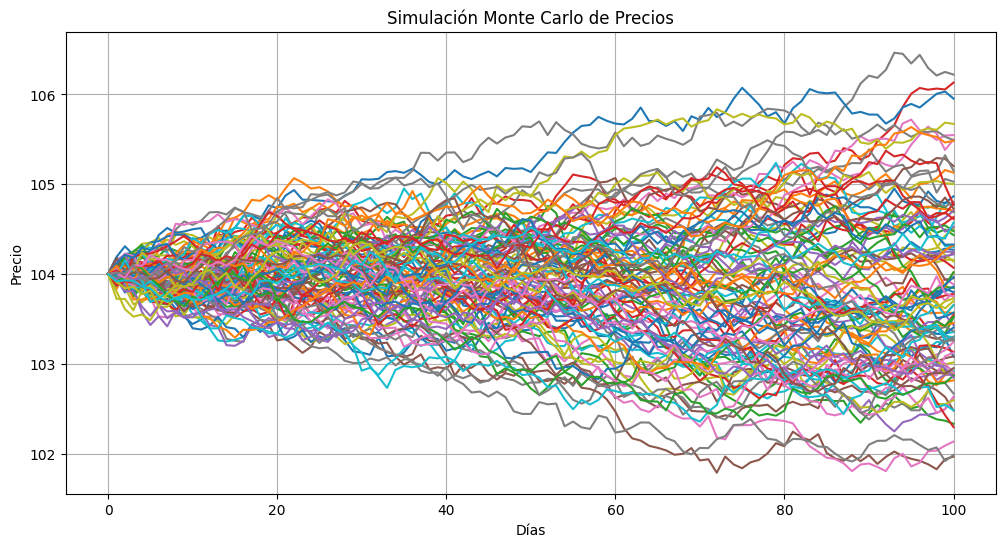

In [165]:
plt.figure(figsize=(12,6))

for simulacion in monte_carlo_simulaciones:
    plt.plot(simulacion)

plt.title('Simulación Monte Carlo de Precios')
plt.xlabel('Días')
plt.ylabel('Precio')
plt.grid(True)

plt.show()

#Predicción precio día siguiente

In [166]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [167]:
# Se extrae la última columna de los precios simulados
ultima_columna = monte_carlo_simulaciones_df.iloc[:,-1]
print(ultima_columna)

0      104.000000
1      103.918984
2      103.928889
3      103.926437
4      103.860043
          ...    
96     104.264477
97     104.416239
98     104.415277
99     104.395900
100    104.573486
Name: 99, Length: 101, dtype: float64


In [168]:
#Precio de cierre número 100
precio_cien = df['Close'][-101]
print(f"El precio de cierre número cien es: $ {precio_cien: .2f}")

El precio de cierre número cien es: $  100.28


/tmp/ipykernel_26803/3328606284.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precio_cien = df['Close'][-101]


In [169]:
#Calcular Ganancias / Pérdidas

Ganancia_Pérdida = []
for precio in ultima_columna:
    ganancia_perdida = precio - precio_cien
    Ganancia_Pérdida.append(ganancia_perdida)

In [183]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T
print(Ganancia_Pérdida)

            0
0    3.716972
1    3.635957
2    3.645862
3    3.643410
4    3.577015
..        ...
96   3.981450
97   4.133212
98   4.132249
99   4.112872
100  4.290458

[101 rows x 1 columns]


In [171]:
#Contar %Ganancias y %Pérdidas si el precio de compra es lo que vale el precio de cierre número cien
if isinstance(Ganancia_Pérdida, list):
    Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T

Ganancia = (Ganancia_Pérdida > 0).sum().sum()
Perdida = (Ganancia_Pérdida < 0).sum().sum()

# Obtener el número total de simulaciones
num_simulaciones = Ganancia_Pérdida.size

# Calcular porcentajes
porcentaje_ganancia = (Ganancia / num_simulaciones) * 100
porcentaje_perdida = (Perdida / num_simulaciones) * 100

print(f"Número de simulaciones con ganancia: {Ganancia} ({porcentaje_ganancia:.2f} %)")
print(f"Número de simulaciones con pérdida: {Perdida} ({porcentaje_perdida:.2f} %)")
print(f"Número total de simulaciones: {num_simulaciones}")

Número de simulaciones con ganancia: 101 (100.00 %)
Número de simulaciones con pérdida: 0 (0.00 %)
Número total de simulaciones: 101


In [172]:
#Ganancia potencial
Ganancia_potencial = Ganancia_Pérdida.mean(axis=1).iloc[0]
print(f"Ganancia Potencial: $ {Ganancia_potencial: .4f}")

Ganancia Potencial: $  3.8743


In [173]:
#Precio Potencial
Precio_potencial = precio_cien + Ganancia_potencial
print(f"Precio Potencial: $ {Precio_potencial: .4f}")

Precio Potencial: $  104.1573


##Estadísticos de Bondad de Ajuste

In [174]:
#Obtener datos
hoy = yf.download('LIVEPOL1.MX', start='2026-06-29', end ='2026-06-30')

/tmp/ipykernel_26803/3446559301.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hoy = yf.download('LIVEPOL1.MX', start='2026-06-29', end ='2026-06-30')
[*********************100%***********************]  1 of 1 completed


In [175]:
# Eliminar nivel del ticker
hoy.columns = hoy.columns.droplevel(1)

In [176]:
Precio_hoy = hoy['Close']
print(Precio_hoy)

Date
2026-06-29    104.0
Name: Close, dtype: float64


In [177]:
comparacion = pd.DataFrame({
    "Real": Precio_hoy,
    "Pronosticado": Precio_potencial
})

print(comparacion)

             Real  Pronosticado
Date                           
2026-06-29  104.0    104.157302


###Error Cuadrático Medio (RMSE)


In [178]:
rmse = np.sqrt(mean_squared_error(hoy['Close'], [Precio_potencial]))
print(f"RMSE Monte Carlo: {rmse:.4f}")

RMSE Monte Carlo: 0.1573


In [179]:
rmse_porcentaje = (rmse / hoy['Close'].mean()) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 0.1513 %


###Error Cuadrático Medio (MAE)

In [180]:
mae = mean_absolute_error(hoy['Close'], [Precio_potencial])

print(f"MAE Monte Carlo: {mae:.4f}")

MAE Monte Carlo: 0.1573


In [181]:
mae_porcentaje = (mae / hoy['Close'].mean()) * 100
print(f"% MAE Monte Carlo: {mae_porcentaje:.4f} %")

% MAE Monte Carlo: 0.1513 %


###Error Porcentual Absoluto Medio (MAPE)

In [182]:
# Using scikit-learn
mape = mean_absolute_percentage_error(hoy['Close'], [Precio_potencial]) * 100
print(f"MAPE: {mape:.4f}%")

MAPE: 0.1513%
